# EDA 10 v6 — Figure 4.5: mechanism geography with balanced diagnostic cases

**Revised 2026-07-29.** This version now **actually adds two super-gentrification
cases from the `outflow-internal-majority` leaf**. They are selected reproducibly
from the joined Yee–mechanism data rather than entered by assumption.

The case roster therefore distinguishes:
- inflow-driven, frame-robust examples;
- temporal changes to Counter-led;
- one outer-London outflow-internal diagnostic case;
- two inner-London `outflow-internal-majority × SupGen` cases;
- outflow-external-majority examples.

This prevents the locator map from representing the entire outflow-internal leaf
through Harrow-type cases alone. The selected SupGen cases are required to be
outflow-internal in both 2011 and 2021, located in statutory Inner London, and to
contain at least one Yee and Dennett SupGen LSOA. Where more than two qualify, the
notebook selects the clearest outflow-dominated profiles using the lowest mean
cascade-inflow share across the two censuses.

**Output:** `outputs/case_study/locator_map/fig_eda10_v6_mechanism_case_locator_20260729.png`


In [1]:
# ── imports & paths (verbatim conventions from eda_10fixed) ──────────────────
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from shapely.geometry import shape
from shapely.ops import unary_union
from pyprojroot import here

plt.rcParams['font.family'] = 'DejaVu Sans'

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs' / 'case_study' / 'locator_map'
BOUNDARIES = DATA_DIR / 'london_msoa_2011.geojson'
EDA4       = ROOT / 'outputs' / 'eda4_results_for_phase3_20260626.csv'
NATF       = DATA_DIR / 'msoa_cascade_national_frame_20260625.csv'
EDA9       = ROOT / 'outputs' / 'eda9_mechanism_tree_20260705.csv'
LOOKUP     = DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv'
YEE_LABELS = DATA_DIR / 'yee_LSOA_labels_forMapping.csv'
LSOA_LOOKUP = ROOT / 'outputs' / 'lsoa11_to_msoa11.csv'
OUT_PNG    = OUT_DIR / 'fig_eda10_v6_mechanism_case_locator_20260729.png'

OUT_DIR.mkdir(parents=True, exist_ok=True)

INNER_LONDON_LADS = {
    'E09000007','E09000001','E09000011','E09000012','E09000013',
    'E09000014','E09000019','E09000020','E09000022','E09000023',
    'E09000025','E09000028','E09000030','E09000032','E09000033',
}

In [2]:
# ── EDA 9 mechanism classes (single interface; inline fallback) ──────────────
INFLOW_MIN = 0.25
EXT_MAJ    = 0.50
LEAVES     = ['inflow-driven', 'frame-sensitive', 'outflow-external', 'outflow-internal']

def _leaf(r, yr):
    if r[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    if r[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN:
        return 'inflow-driven' if r[f'Typ_A_{yr}'] == 'Cascade-led' else 'frame-sensitive'
    return 'outflow-external' if r[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ else 'outflow-internal'

if EDA9.exists():
    e9 = pd.read_csv(EDA9)
    rename = {'frame-sensitive inflow': 'frame-sensitive',
              'outflow: external-majority': 'outflow-external',
              'outflow: internal-majority': 'outflow-internal'}
    for yr in ('11', '21'):
        e9[f'leaf_{yr}'] = e9[f'leaf_{yr}'].replace(rename)
    print(f'loaded mechanism classes from {EDA9.name}')
else:
    e4 = pd.read_csv(EDA4)
    nf = pd.read_csv(NATF)
    e9 = e4.merge(nf[['msoa11cd',
                      'Outflow_Poorer_nat_11', 'Ext_Outflow_nat_11',
                      'Outflow_Poorer_nat_21', 'Ext_Outflow_nat_21']],
                  on='msoa11cd', validate='1:1')
    for yr in ('11', '21'):
        arm = e9[f'Outflow_Poorer_nat_{yr}'].replace(0, np.nan)
        e9[f'Ext_Arm_Share_{yr}'] = np.where(e9['Wealth_Decile_National'] > 6,
                                             e9[f'Ext_Outflow_nat_{yr}'] / arm, 0.0)
        e9[f'Ext_Arm_Share_{yr}'] = e9[f'Ext_Arm_Share_{yr}'].fillna(0.0)
        e9[f'leaf_{yr}'] = e9.apply(_leaf, axis=1, yr=yr)
    print('EDA 9 export not found — computed mechanism tree inline (identical rules)')

# guard: EDA 9 leaf counts
assert e9['leaf_11'].value_counts().to_dict() == {'outflow-internal': 81, 'frame-sensitive': 57,
                                                  'inflow-driven': 56, 'outflow-external': 19}
assert e9['leaf_21'].value_counts().to_dict() == {'outflow-internal': 90, 'outflow-external': 78,
                                                  'frame-sensitive': 14, 'inflow-driven': 13}
print('leaf counts reproduce EDA 9 exactly')

loaded mechanism classes from eda9_mechanism_tree_20260705.csv
leaf counts reproduce EDA 9 exactly


In [3]:
# ── colour grammar: flow_yee_palette_v2 (same fills as Figure 4.6) ─────────
try:
    from flow_yee_palette_v2 import FLOW_FILL, FLOW_ALPHA, FLOW_DRAW_ORDER, FLOW_LABEL
    print('palette v2.1 imported from flow_yee_palette_v2.py')
except ImportError:
    print('flow_yee_palette_v2.py not found at project root — inline fallback '
          '(identical values; place the module at ROOT so Figures 4.5/4.6 share it)')
    FLOW_FILL = {'inflow-driven': '#99000d', 'frame-sensitive': '#e6ab02',
                 'outflow-external': '#e64a2e', 'outflow-internal': '#f8875f',
                 'counter': '#9db8ce', 'other': '#e9e7e2'}
    FLOW_ALPHA = {'inflow-driven': 0.95, 'frame-sensitive': 0.90,
                  'outflow-external': 0.95, 'outflow-internal': 0.95,
                  'counter': 0.85, 'other': 1.00}
    FLOW_DRAW_ORDER = ('other', 'counter', 'outflow-internal',
                       'outflow-external', 'frame-sensitive', 'inflow-driven')
    FLOW_LABEL = {'inflow-driven': 'Inflow-driven cascade — frame-robust, inflow-led',
                  'frame-sensitive': 'Frame-sensitive inflow — residual',
                  'outflow-external': 'Outflow cascade — external-majority',
                  'outflow-internal': 'Outflow cascade — internal-majority',
                  'counter': 'Counter-led', 'other': 'Symmetric / Lateral'}

palette v2.1 imported from flow_yee_palette_v2.py


In [4]:
# ── balanced case roster, including SupGen × outflow-internal cases ─────────
# Existing diagnostic cases
CASES_INFLOW_ROBUST = {
    'E02000191': 'Camden 026',
    'E02000873': 'Tower Hamlets 010',
}

CASES_TEMPORAL_CHANGE = {
    'E02000809': 'Southwark 003',
    'E02000561': 'Islington 008',
    'E02000957': 'Wandsworth 035',
}

# Retain one outer-London outflow-internal example, rather than two.
CASES_OUTFLOW_INTERNAL_OUTER = {
    'E02000440': 'Harrow 008',
}

CASES_OUTFLOW_EXTERNAL = {
    'E02000616': 'Kingston upon Thames 019',
    'E02000237': 'Croydon 044',
}

# Build the any-SupGen MSOA indicator using the same aggregation as EDA 12.
yee = pd.read_csv(YEE_LABELS).rename(columns={'LSOA_Code': 'lsoa11cd'})
lsoa_lk = pd.read_csv(LSOA_LOOKUP)[['lsoa11cd', 'msoa11cd']].drop_duplicates().dropna()
supgen_msoas = set(
    yee.loc[yee['Class_3_status'].eq('SupGen'), ['lsoa11cd']]
       .merge(lsoa_lk, on='lsoa11cd', how='inner')['msoa11cd']
)

# Obtain MSOA names and LAD codes from the identification lookup.
msoa_lk = pd.read_csv(LOOKUP, encoding='utf-8-sig')
name_candidates = ['MSOA11NM', 'MSOA11HCLNM', 'msoa11nm', 'msoa11hclnm']
name_col = next((c for c in name_candidates if c in msoa_lk.columns), None)
if name_col is None:
    raise KeyError(f'No MSOA-name column found in {LOOKUP.name}: {list(msoa_lk.columns)}')
msoa_name = dict(zip(msoa_lk['MSOA11CD'], msoa_lk[name_col]))
msoa_lad = dict(zip(msoa_lk['MSOA11CD'], msoa_lk['LAD22CD']))

# Select inner-London SupGen cases that remain outflow-internal in both years.
# The mean inflow share ranks the clearest outflow-dominated examples first.
sup_candidates = e9[
    e9['msoa11cd'].isin(supgen_msoas)
    & e9['leaf_11'].eq('outflow-internal')
    & e9['leaf_21'].eq('outflow-internal')
    & e9['msoa11cd'].map(msoa_lad).isin(INNER_LONDON_LADS)
].copy()

sup_candidates['mean_cascade_inflow_share'] = (
    sup_candidates['Casc_Inflow_Share_11'] + sup_candidates['Casc_Inflow_Share_21']
) / 2
sup_candidates = sup_candidates.sort_values(
    ['mean_cascade_inflow_share', 'msoa11cd'], ascending=[True, True]
)

if len(sup_candidates) < 2:
    raise ValueError(
        'Fewer than two persistent Inner-London SupGen × outflow-internal cases were found. '
        'Inspect the Yee join and mechanism classifications before plotting.'
    )

selected_sup = sup_candidates.head(2)
CASES_OUTFLOW_INTERNAL_SUPGEN = {
    row.msoa11cd: msoa_name.get(row.msoa11cd, row.msoa11cd)
    for row in selected_sup.itertuples()
}

print('Selected SupGen × outflow-internal cases:')
print(selected_sup[['msoa11cd', 'Casc_Inflow_Share_11', 'Casc_Inflow_Share_21',
                     'Ext_Arm_Share_11', 'Ext_Arm_Share_21']]
      .assign(name=lambda d: d['msoa11cd'].map(msoa_name))
      .to_string(index=False))

CASES_ALL = {
    **CASES_INFLOW_ROBUST,
    **CASES_TEMPORAL_CHANGE,
    **CASES_OUTFLOW_INTERNAL_OUTER,
    **CASES_OUTFLOW_INTERNAL_SUPGEN,
    **CASES_OUTFLOW_EXTERNAL,
}
CASES_BY_YEAR = {'11': CASES_ALL, '21': CASES_ALL}

# Existing hand-tuned offsets. Newly selected SupGen cases use an automatic
# centroid-based offset and can be fine-tuned after the first render.
LABEL_OFF = {
    'Camden 026':        (-0.115,  0.016),
    'Tower Hamlets 010': ( 0.105,  0.026),
    'Southwark 003':     ( 0.095, -0.052),
    'Islington 008':     ( 0.090,  0.040),
    'Wandsworth 035':    (-0.035, -0.062),
    'Harrow 008':        ( 0.088,  0.032),
    'Kingston upon Thames 019': (-0.095, -0.045),
    'Croydon 044':       ( 0.090, -0.040),
}

LABEL_YEARS = {name: ('11', '21') for name in CASES_ALL.values()}


Selected SupGen × outflow-internal cases:
 msoa11cd  Casc_Inflow_Share_11  Casc_Inflow_Share_21  Ext_Arm_Share_11  Ext_Arm_Share_21            name
E02000978              0.019533              0.027778          0.157920          0.224286 Westminster 019
E02000837              0.023585              0.026927          0.342995          0.387405   Southwark 031


In [5]:
# ── geometry (verbatim from eda_10fixed): WGS84 geojson + LAD22 inner union ──
gj = json.load(open(BOUNDARIES))
geoms, codes = [], []
for ft in gj['features']:
    geoms.append(shape(ft['geometry']))
    codes.append(ft['properties']['MSOA11CD'])

def rings(geom):
    if geom.geom_type == 'Polygon':
        polys = [geom]
    elif geom.geom_type == 'MultiPolygon':
        polys = geom.geoms
    elif geom.geom_type == 'GeometryCollection':
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon']
    else:
        polys = []
    return [np.asarray(p.exterior.coords) for p in polys]

lookup = pd.read_csv(LOOKUP, encoding='utf-8-sig')          # first column has a BOM
msoa2lad = dict(zip(lookup['MSOA11CD'], lookup['LAD22CD']))
lads = [msoa2lad.get(c, '') for c in codes]

london = unary_union(geoms)
inner  = unary_union([g for g, l in zip(geoms, lads) if l in INNER_LONDON_LADS])
assert not inner.is_empty, 'Inner London union came back empty — check LAD mapping'
print(f'{len(geoms)} MSOA geometries loaded')

983 MSOA geometries loaded


In [6]:
# ── per-year six-class map categories (fig2 logic from eda_10fixed) ──────────
def fig_class(r, yr):
    if isinstance(r[f'leaf_{yr}'], str):
        return r[f'leaf_{yr}']
    return 'counter' if r[f'Typ_C_{yr}'] == 'Counter-led' else 'other'

cat, counts = {}, {}
for yr in ('11', '21'):
    e9[f'figcls_{yr}'] = e9.apply(fig_class, axis=1, yr=yr)
    d = dict(zip(e9['msoa11cd'], e9[f'figcls_{yr}']))
    d['E02000190'] = d.get('E02000189', 'other')            # Camden 024/025 merge
    cat[yr] = d
    counts[yr] = e9[f'figcls_{yr}'].value_counts()
    print(f'20{yr}:', counts[yr].to_dict())

2011: {'other': 489, 'counter': 280, 'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
2021: {'counter': 452, 'other': 335, 'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13}


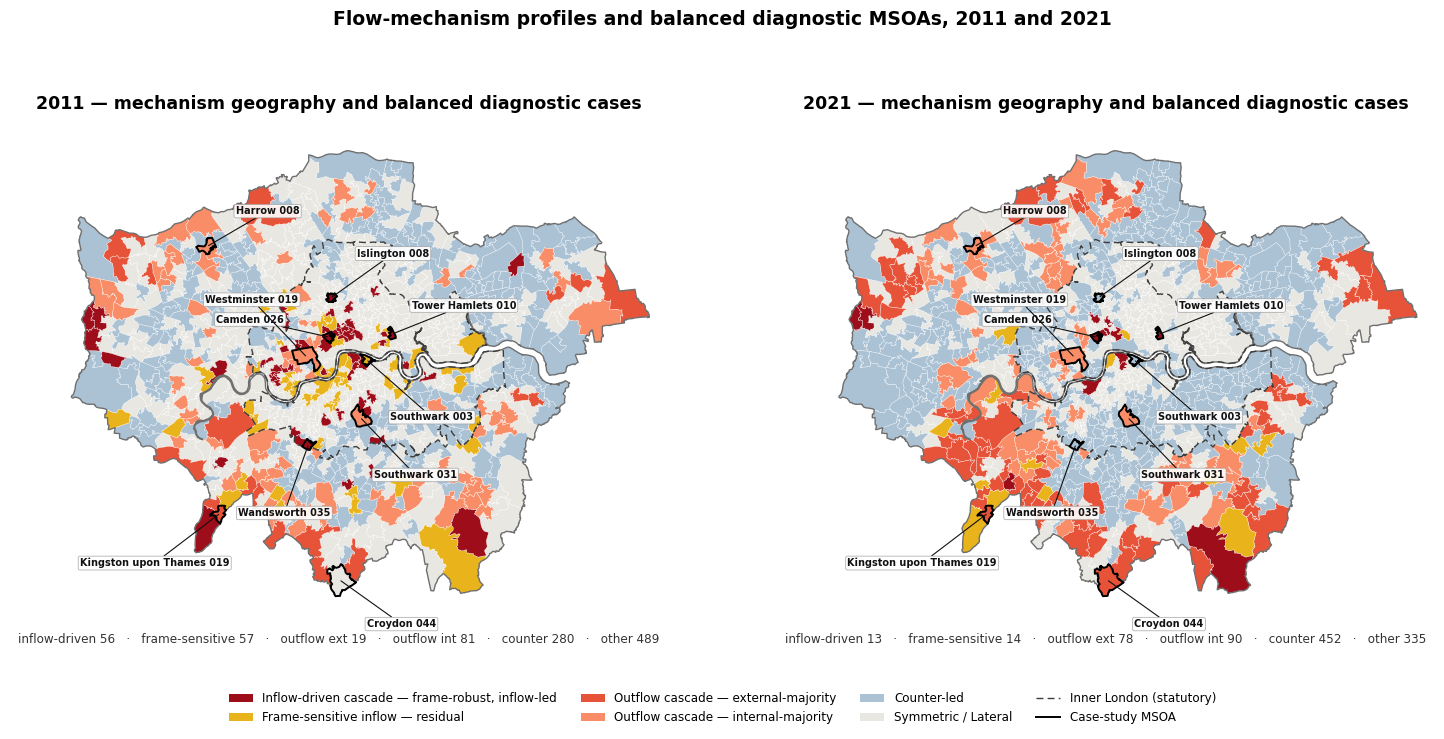

saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/locator_map/fig_eda10_v6_mechanism_case_locator_20260729.png


In [7]:
# ── Figure 4.5: two-panel mechanism geography with case exemplars ────────────
TITLES = {'11': '2011 — mechanism geography and balanced diagnostic cases',
          '21': '2021 — mechanism geography and balanced diagnostic cases'}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.4))

for ax, yr in zip(axes, ('11', '21')):
    for c in FLOW_DRAW_ORDER:
        polys = [r for g, code in zip(geoms, codes)
                 if cat[yr].get(code, 'other') == c for r in rings(g)]
        if polys:
            ax.add_collection(PolyCollection(polys, facecolor=FLOW_FILL[c],
                                             edgecolor='white', linewidth=0.25,
                                             alpha=FLOW_ALPHA[c], zorder=2))
    for r in rings(london):
        ax.plot(r[:, 0], r[:, 1], color='#6f6f6f', lw=1.0, zorder=5)
    for r in rings(inner):
        ax.plot(r[:, 0], r[:, 1], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)), zorder=5)

    fs = 7.0                          # both panels carry all nine labels
    for code, name in CASES_BY_YEAR[yr].items():
        g = geoms[codes.index(code)]
        ax.add_collection(PolyCollection(rings(g), facecolor='none',
                                         edgecolor='black', linewidth=1.4, zorder=6))
        if yr in LABEL_YEARS.get(name, ()):
            cx, cy = g.centroid.x, g.centroid.y
            if name in LABEL_OFF:
                dx, dy = LABEL_OFF[name]
            else:
                # Automatic first-pass placement for dynamically selected SupGen cases.
                # Place central/inner-western labels outward from the map centre.
                dx = -0.080 if cx < -0.10 else 0.080
                dy = 0.052 if cy >= 51.50 else -0.052
            ax.annotate(name, xy=(cx, cy), xytext=(cx + dx, cy + dy),
                        fontsize=fs, fontweight='bold', color='#111',
                        ha='center', va='center', zorder=8,
                        arrowprops=dict(arrowstyle='-', color='#111', lw=0.8,
                                        shrinkA=0, shrinkB=1),
                        bbox=dict(boxstyle='round,pad=0.18', fc='white',
                                  ec='#999', lw=0.5, alpha=0.9))

    n = counts[yr]
    ax.set_title(TITLES[yr], fontsize=12.5, fontweight='bold', pad=8)
    ax.text(0.5, -0.015,
            f"inflow-driven {n.get('inflow-driven',0)}   ·   frame-sensitive {n.get('frame-sensitive',0)}   ·   "
            f"outflow ext {n.get('outflow-external',0)}   ·   outflow int {n.get('outflow-internal',0)}   ·   "
            f"counter {n.get('counter',0)}   ·   other {n.get('other',0)}",
            transform=ax.transAxes, ha='center', va='top', fontsize=8.6, color='#333')
    ax.set_aspect(1.0 / np.cos(np.radians(51.5)))
    ax.set_xlim(-0.60, 0.36); ax.set_ylim(51.26, 51.72)
    ax.set_axis_off()

handles = ([mpatches.Patch(fc=FLOW_FILL[c], alpha=FLOW_ALPHA[c], label=FLOW_LABEL[c])
            for c in ('inflow-driven', 'frame-sensitive', 'outflow-external',
                      'outflow-internal', 'counter', 'other')] +
           [Line2D([0], [0], color='#3d3d3d', lw=1.0, ls=(0, (5, 3)),
                   label='Inner London (statutory)'),
            Line2D([0], [0], color='black', lw=1.4, label='Case-study MSOA')])
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           fontsize=8.6, bbox_to_anchor=(0.5, 0.005))

fig.suptitle('Flow-mechanism profiles and balanced diagnostic MSOAs, 2011 and 2021',
             fontsize=13.5, fontweight='bold', y=0.985)

plt.tight_layout(rect=[0, 0.085, 1, 0.95])
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved {OUT_PNG}')

## Draft caption (end of §4.5)

> **Figure 4.5. Spatial distribution of Frame C mechanism profiles and selected
> diagnostic MSOAs, 2011 and 2021.** Area fills show the six-class mechanism
> classification. The labelled cases include inflow-driven examples, temporal
> transitions, outflow-external examples, one outer-London outflow-internal case,
> and two Inner-London MSOAs that are both outflow-internal-majority in the two
> censuses and contain at least one Yee and Dennett super-gentrification LSOA.
> The latter cases show that the outflow-internal profile is not represented only
> by ladder-sensitive outer-London examples. Full flow decompositions are reported
> in Figure 4.6 and Appendix X.

## Selection note

The two SupGen cases are selected programmatically from the joined data. They must:
1. contain at least one SupGen LSOA;
2. be `outflow-internal` in both 2011 and 2021;
3. lie in statutory Inner London; and
4. rank among the two lowest mean cascade-inflow shares among qualifying cases.

After the first render, adjust only their label offsets if needed; do not replace
the selected cases manually unless a substantive case-quality check warrants it.
